# House Price Prediction
## Task 1: Data Loading & Exploration
In this task, the housing dataset is loaded using Pandas. The first few records are examined to understand the structure of the dataset. The dimensions, column names, data types, and missing values are checked to gain an initial understanding of the data before preprocessing.

In [ ]:
import pandas as pd
df=pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Dataset Shape

The shape of the dataset helps identify the total number of observations (rows) and features (columns) available for analysis.

In [3]:
df.shape

(545, 13)

### Column Information

The column names and data types are inspected to identify numerical and categorical variables.

### Target Variable and Features
The target variable for prediction is **price**, while all remaining columns act as input features.

In [6]:
y=df["price"]
X=df.drop('price',axis=1)
X 

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [7]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

### Missing Value Analysis

Missing values can affect model performance. Therefore, each column is checked for null values.

In [21]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2: Data Cleaning

Data cleaning is performed to improve the quality of the dataset. Duplicate records are removed, missing values are handled, and categorical features are converted into numerical format for machine learning algorithms.

In [22]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Removing Duplicate Records

Duplicate entries may introduce bias and therefore should be removed.

In [23]:
df.drop_duplicates(inplace=True)
print("New Shape:", df.shape)

New Shape: (545, 13)


There are no missing values in any column or row.

### Encoding Categorical Features

Machine learning models require numerical input. Therefore, categorical variables are converted using One-Hot Encoding.

### Converting Boolean Values to Numeric Format

After one-hot encoding, some categorical features are represented as True and False values. These are converted into 1 and 0 respectively to ensure consistency and improve readability for machine learning analysis.

In [27]:
df = pd.get_dummies(df, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
for col in bool_cols:
    df[col] = df[col].astype(int)
df.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
5,10850000,7500,3,3,1,2,1,0,1,0,1,1,1,0
6,10150000,8580,4,3,4,2,1,0,0,0,1,1,1,0
7,10150000,16200,5,3,2,0,1,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,2,1,1,1,0,1,1,0,0
9,9800000,5750,3,2,4,1,1,1,0,0,1,1,0,1


## Task 3: Model Building

The cleaned dataset is divided into training and testing sets. Two regression models are trained and compared:
1. Linear Regression
2. Random Forest Regressor

Performance is evaluated using MAE, RMSE, and R² Score.

In [29]:
from sklearn.model_selection import train_test_split
X = df.drop("price", axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42)
print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


### Linear Regression Model

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
MAE: 970043.4039201637
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


### Random Forest Regressor

In [31]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


### Model Comparison

The evaluation metrics of both models are compared to determine which model predicts house prices more accurately.

In [32]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[lr_mae,rf_mae],
    "RMSE":[lr_rmse,rf_rmse],
    "R2 Score":[lr_r2,rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


# Task 4: Data Visualization

Visualizations help understand the distribution of house prices, relationships between variables, and the performance of the prediction model.

### Chart 1: Distribution of House Prices

This histogram shows how house prices are distributed throughout the dataset. It helps identify whether prices are concentrated within a certain range or spread across multiple price levels.

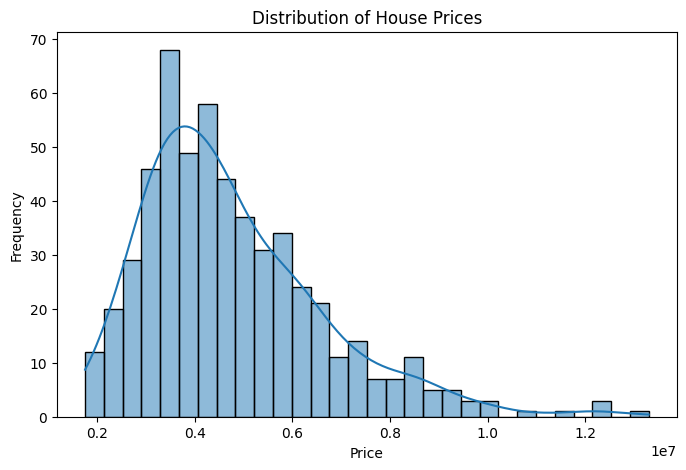

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("chart1_price_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

### Chart 2: Correlation Heatmap

The heatmap illustrates the correlation between all features and house price. Strong positive correlations indicate features that significantly influence property value.

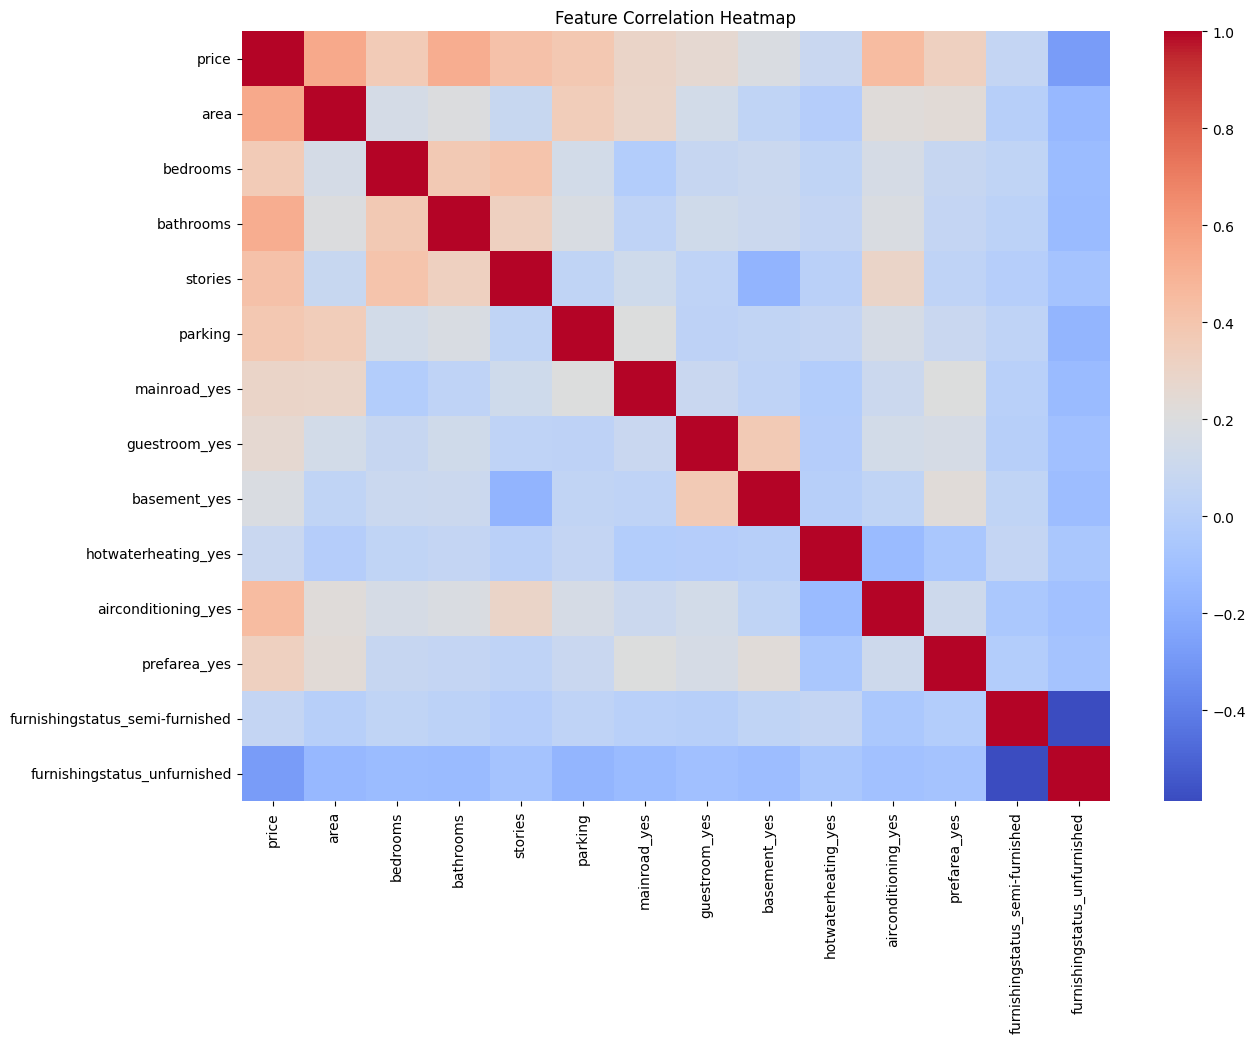

In [38]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),cmap="coolwarm",annot=False)
plt.title("Feature Correlation Heatmap")
plt.savefig("chart2_correlation_heatmap.png",bbox_inches='tight', dpi=300)
plt.show()

### Chart 3: Actual vs Predicted Prices

This scatter plot compares actual house prices with the values predicted by the Linear Regression model. Points closer to the diagonal indicate more accurate predictions.

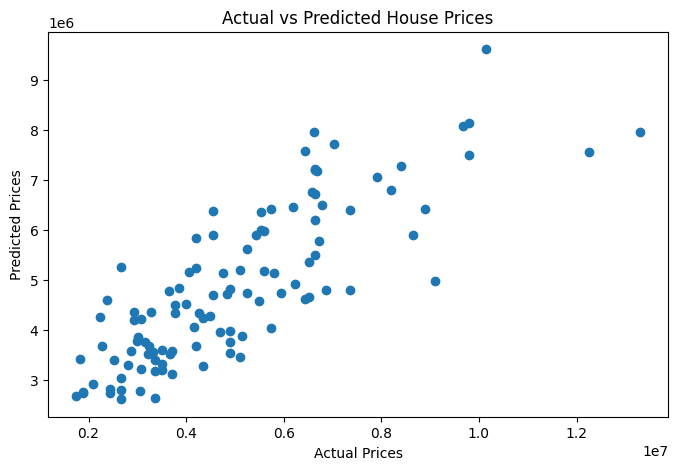

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.savefig("chart3_actual_vs_predicted.png",bbox_inches='tight', dpi=300)
plt.show()

# Task 5: Insights & Summary

The objective of this project was to predict house prices using machine learning techniques and identify the factors that most influence property value.

From the correlation analysis, area, bathrooms, stories, air conditioning, and parking were found to have the strongest positive relationship with house price. Larger houses with more amenities generally tend to be more expensive.

Two regression models were trained and evaluated. Linear Regression achieved an R² Score of approximately 0.65, outperforming the Random Forest Regressor on this dataset. This indicates that the Linear Regression model was able to explain about 65% of the variation in house prices.

The distribution of house prices showed that most properties fall within the lower to middle price range, while only a few houses have exceptionally high prices. This creates a right-skewed distribution.

One interesting observation was that location-related and convenience-related features, such as preferred area and air conditioning, contributed significantly to property value.

Based on these findings, real estate businesses should focus on properties with larger areas, additional bathrooms, parking facilities, and modern amenities, as these characteristics are associated with higher market prices.